# Lab 05 — Sensory Processing & AI Perception
## ITAI 4374: Neuroscience as a Model for AI

---

**Module 05** taught us how the brain transforms raw physical energy — light, sound, pressure — into the rich perceptual world we experience. In this lab, you will *become* the sensory system: applying the same computational principles the brain uses, then comparing them to what artificial neural networks learn on their own.

---

### 🛤️ Two Tracks — Read This First

This lab has **two tracks** depending on your computing resources:

| Badge | Meaning | Who |
|-------|---------|-----|
| 🟢 **ALL STUDENTS** | Core exercises — **everyone completes these** | All students |
| 🔵 **GPU TRACK** | Optional enrichment — requires a GPU runtime | Students with GPU access (e.g., Colab GPU) |

**If you do NOT have GPU access:**
- Complete all 🟢 cells
- **Skip** all 🔵 cells — pre-computed results are provided so you can still answer reflection questions
- You will NOT lose points for skipping 🔵 cells

**If you DO have GPU access:**
- Complete all 🟢 cells AND all 🔵 cells
- 🔵 cells give you hands-on experience training small models
- To enable GPU in Colab: `Runtime → Change runtime type → T4 GPU`

---

### Lab Structure

| Part | Title | Track | Estimated Time |
|------|-------|-------|----------------|
| A | "Be the Retina" — Biological Image Filtering | 🟢 All | 30–40 min |
| B | "Inside a CNN" — Comparing Bio vs. Artificial Features | 🟢 + 🔵 | 30–40 min |
| C | "Hearing in Pictures" — Auditory Processing | 🟢 + 🔵 | 25–35 min |
| D | Experiments | 🟢 All | 20–30 min |
| E | Reflections | 🟢 All | 15–20 min |

**Total estimated time:** 2–2.5 hours

---

### What to Submit

1. This completed notebook (`.ipynb`) with all code cells executed and all text responses filled in
2. Name your file: `L05_YourName_ITAI4374.ipynb`
3. Upload to the Canvas assignment

---

## 🟢 Setup — Run This First

Run the cell below to install and import everything you need. This works on **CPU only** — no GPU required.

In [2]:
# ============================================================
# SETUP — Run this cell first (CPU only, no GPU needed)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal, ndimage
from PIL import Image
import io, os, warnings
warnings.filterwarnings('ignore')

# Check if GPU is available (for track selection)
try:
    import torch
    import torchvision
    GPU_AVAILABLE = torch.cuda.is_available()
    DEVICE = 'cuda' if GPU_AVAILABLE else 'cpu'
    print(f"PyTorch version: {torch.__version__}")
    print(f"GPU available: {GPU_AVAILABLE}")
    if GPU_AVAILABLE:
        print(f"GPU name: {torch.cuda.get_device_name(0)}")
        print("✅ You can complete both 🟢 and 🔵 track exercises!")
    else:
        print("ℹ️ No GPU detected — complete all 🟢 exercises. Skip 🔵 cells.")
except ImportError:
    GPU_AVAILABLE = False
    DEVICE = 'cpu'
    print("ℹ️ PyTorch not available — complete all 🟢 exercises. Skip 🔵 cells.")

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['font.size'] = 11

print("\n✅ Setup complete!")

PyTorch version: 2.10.0+cu128
GPU available: True
GPU name: Tesla T4
✅ You can complete both 🟢 and 🔵 track exercises!

✅ Setup complete!


## 🟢 Generate Sample Images

Instead of downloading large datasets, we will **create** our test images programmatically. This keeps the lab lightweight and ensures it runs on any machine.

Run the cell below — it creates three test images that mimic what the visual system encounters.

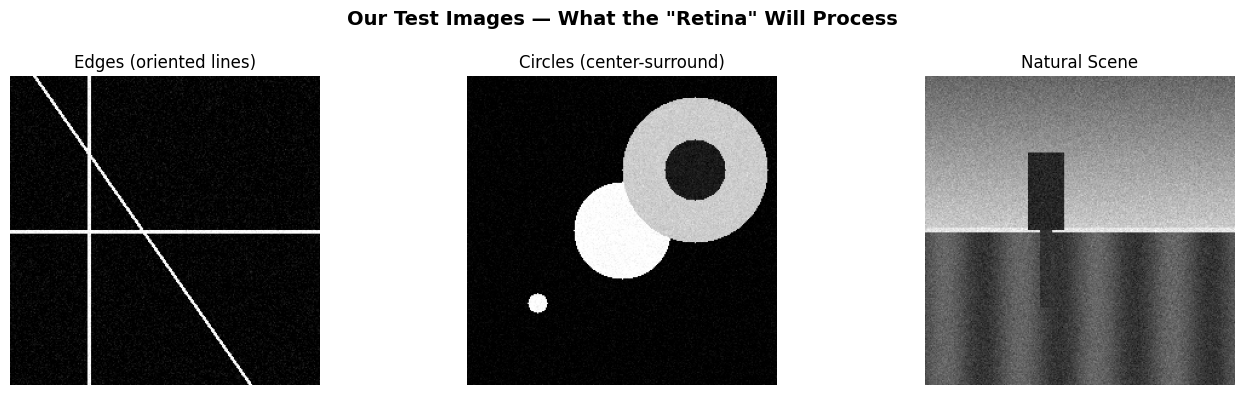

✅ Three test images generated (256×256 pixels each, no files downloaded)


In [3]:
# ============================================================
# Generate test images (no downloads needed)
# ============================================================
np.random.seed(42)

def make_edges_image(size=256):
    """Image with clear edges at different orientations."""
    img = np.zeros((size, size), dtype=np.float64)
    # Vertical edge
    img[:, size//4:size//4+3] = 1.0
    # Horizontal edge
    img[size//2:size//2+3, :] = 1.0
    # Diagonal edge
    for i in range(size):
        j = int(i * 0.7) + 20
        if 0 <= j < size:
            img[i, max(0,j-1):min(size,j+2)] = 1.0
    # Add some noise (realistic — retinal signals are noisy)
    img += np.random.normal(0, 0.05, img.shape)
    return np.clip(img, 0, 1)

def make_circles_image(size=256):
    """Image with circular features — tests center-surround responses."""
    img = np.zeros((size, size), dtype=np.float64)
    y, x = np.ogrid[-size//2:size//2, -size//2:size//2]
    # Bright circle on dark background
    mask1 = x**2 + y**2 <= 40**2
    img[mask1] = 1.0
    # Dark circle on bright patch
    bright_patch = (x-60)**2 + (y+50)**2 <= 60**2
    dark_circle = (x-60)**2 + (y+50)**2 <= 25**2
    img[bright_patch] = 0.8
    img[dark_circle] = 0.1
    # Small dot (tests fine resolution)
    dot = (x+70)**2 + (y-60)**2 <= 8**2
    img[dot] = 1.0
    img += np.random.normal(0, 0.03, img.shape)
    return np.clip(img, 0, 1)

def make_natural_scene(size=256):
    """Synthetic 'natural' scene with textures and gradients."""
    img = np.zeros((size, size), dtype=np.float64)
    # Sky gradient (top)
    for i in range(size//2):
        img[i, :] = 0.4 + 0.4 * (i / (size//2))
    # Ground texture (bottom)
    for i in range(size//2, size):
        img[i, :] = 0.3 + 0.1 * np.sin(np.arange(size) * 0.1)
    # Horizon line
    img[size//2-2:size//2+2, :] = 0.9
    # "Tree" rectangle
    img[size//4:size//2, size//3:size//3+30] = 0.15
    img[size//2:3*size//4, size//3+10:size//3+20] = 0.2
    img += np.random.normal(0, 0.04, img.shape)
    return np.clip(img, 0, 1)

# Generate the three images
img_edges = make_edges_image()
img_circles = make_circles_image()
img_scene = make_natural_scene()

# Display them
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ['Edges (oriented lines)', 'Circles (center-surround)', 'Natural Scene']
for ax, img, title in zip(axes, [img_edges, img_circles, img_scene], titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=12)
    ax.axis('off')
plt.suptitle('Our Test Images — What the "Retina" Will Process', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Three test images generated (256×256 pixels each, no files downloaded)")

---

# Part A: "Be the Retina" — Biological Image Filtering

## 🟢 ALL STUDENTS

In Module 05 you learned that the retina is not a passive camera — it already **computes**. Retinal ganglion cells have **center-surround receptive fields** that detect local contrast, not absolute brightness. This is the very first stage of visual processing.

In this part, you will implement these biological operations as image filters and observe what the retina "sees."

---

### A.1 Center-Surround Receptive Fields (Retinal Ganglion Cells)

A retinal ganglion cell responds to a small patch of the visual field called its **receptive field**. An ON-center cell fires when the center of its receptive field is bright and the surround is dark. An OFF-center cell does the opposite.

Mathematically, this is modeled as a **Difference of Gaussians (DoG)** — a narrow Gaussian (the center) minus a wider Gaussian (the surround).

**TODO 1:** Complete the function below to create a center-surround filter.

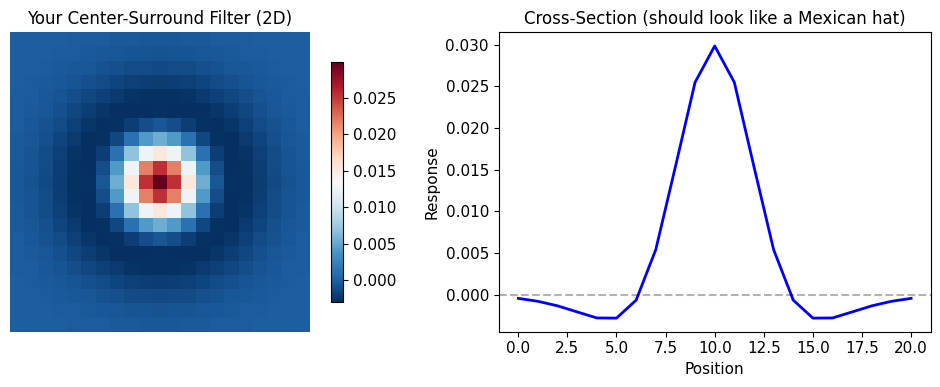

✅ Checkpoint passed! Positive center, negative surround — just like a real ganglion cell.


In [4]:
# ============================================================
# TODO 1: Create a center-surround (Difference of Gaussians) filter
# ============================================================

def make_center_surround(size=21, sigma_center=2.0, sigma_surround=4.0):
    ax = np.arange(-size // 2 + 1, size // 2 + 1)
    x, y = np.meshgrid(ax, ax)

    center = np.exp(-(x**2 + y**2) / (2 * sigma_center**2)) / (2 * np.pi * sigma_center**2)
    surround = np.exp(-(x**2 + y**2) / (2 * sigma_surround**2)) / (2 * np.pi * sigma_surround**2)

    dog = center - surround
    return dog


# Test your filter
dog_filter = make_center_surround()

# Checkpoint: If correct, you should see a bright center and dark surround
if dog_filter is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im = axes[0].imshow(dog_filter, cmap='RdBu_r')
    axes[0].set_title('Your Center-Surround Filter (2D)', fontsize=12)
    axes[0].axis('off')
    plt.colorbar(im, ax=axes[0], shrink=0.8)

    # Cross-section through the middle
    mid = dog_filter.shape[0] // 2
    axes[1].plot(dog_filter[mid, :], 'b-', linewidth=2)
    axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[1].set_title('Cross-Section (should look like a Mexican hat)', fontsize=12)
    axes[1].set_xlabel('Position')
    axes[1].set_ylabel('Response')
    plt.tight_layout()
    plt.show()

    # Validation
    if dog_filter[mid, mid] > 0 and dog_filter[mid, 0] < 0:
        print("✅ Checkpoint passed! Positive center, negative surround — just like a real ganglion cell.")
    else:
        print("⚠️ Check your filter — center should be positive, surround should be negative.")
else:
    print("❌ Filter is None — fill in the YOUR CODE HERE section above.")

### A.2 Apply the Center-Surround to Our Images

Now let's see what the retina "sees" when it processes our test images through center-surround receptive fields.

**TODO 2:** Apply your DoG filter to all three test images using `scipy.ndimage.convolve`.

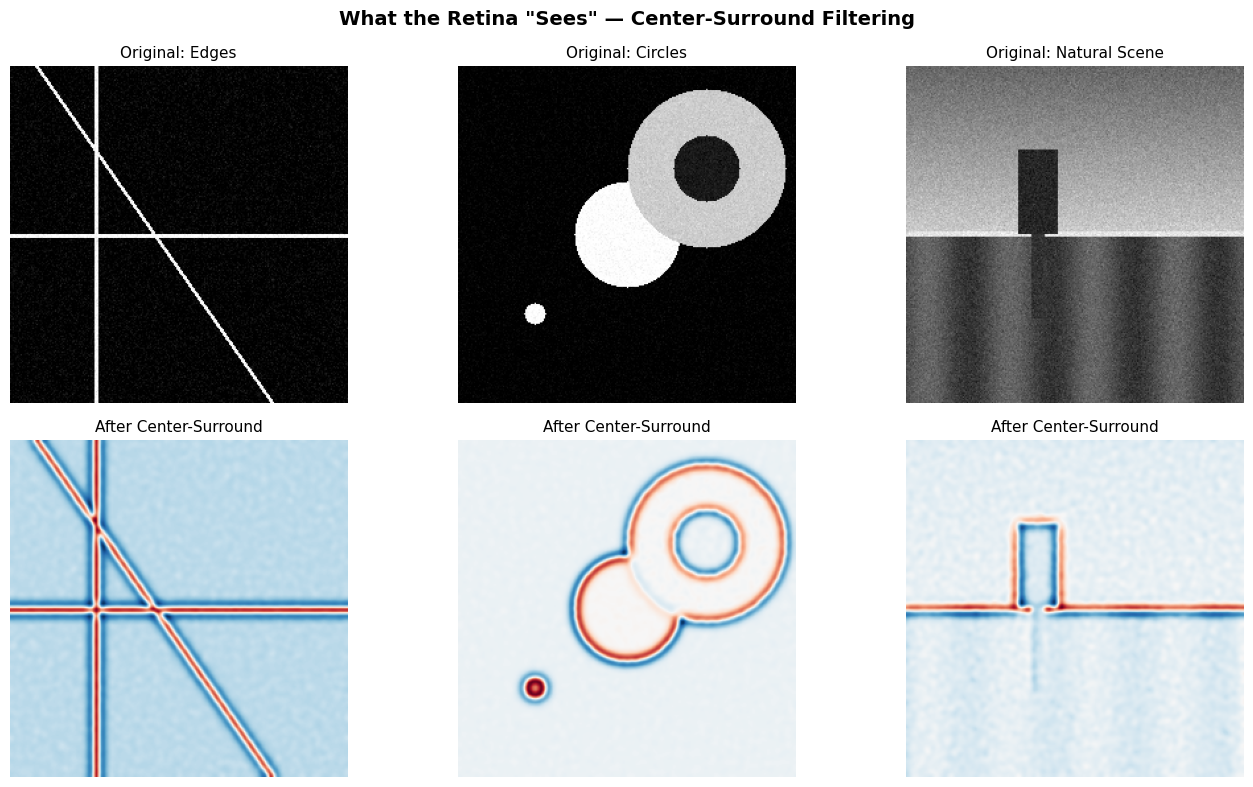

✅ Notice how uniform regions become flat (near zero) — the retina ignores constant brightness!
   It only responds to CHANGES and EDGES. This is lateral inhibition in action.


In [5]:
# ============================================================
# TODO 2: Apply center-surround filter to all three images
# ============================================================

# YOUR CODE HERE — apply the dog_filter to each image using ndimage.convolve
# Hint: result = ndimage.convolve(image, filter)
edges_filtered = ndimage.convolve(img_edges, dog_filter)
circles_filtered = ndimage.convolve(img_circles, dog_filter)
scene_filtered = ndimage.convolve(img_scene, dog_filter)


# Visualization (runs once you fill in the code above)
if edges_filtered is not None:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    originals = [img_edges, img_circles, img_scene]
    filtered = [edges_filtered, circles_filtered, scene_filtered]
    titles = ['Edges', 'Circles', 'Natural Scene']

    for i in range(3):
        axes[0, i].imshow(originals[i], cmap='gray', vmin=0, vmax=1)
        axes[0, i].set_title(f'Original: {titles[i]}', fontsize=11)
        axes[0, i].axis('off')

        axes[1, i].imshow(filtered[i], cmap='RdBu_r')
        axes[1, i].set_title(f'After Center-Surround', fontsize=11)
        axes[1, i].axis('off')

    plt.suptitle('What the Retina "Sees" — Center-Surround Filtering', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("✅ Notice how uniform regions become flat (near zero) — the retina ignores constant brightness!")
    print("   It only responds to CHANGES and EDGES. This is lateral inhibition in action.")
else:
    print("❌ Fill in TODO 2 above.")

### ❓ Knowledge Check 1

Answer in the cell below:

**Q1.1:** Look at the center-surround filtered images above. Why do uniform (constant brightness) regions appear as near-zero (flat gray) after filtering? What biological principle does this demonstrate?

*Your answer:* Uniform regions appear near zero because the brightness in the center and surround is the same, so the filter cancels the values out. This demonstrates lateral inhibition, where the visual system emphasizes changes in brightness rather than constant light.


**Q1.2:** In the circles image, which features produce the STRONGEST response after center-surround filtering — the edges of the circles or the interiors? Why does this make biological sense?

*Your answer:* The edges of the circles produce the strongest response because there is a sharp change in brightness between the circle and the background. This makes sense biologically because the visual system is designed to detect edges and contrasts to identify shapes and objects.



---

### A.3 Gabor Filters — Mimicking V1 Simple Cells

After the retina, visual signals travel to the primary visual cortex (V1). Hubel and Wiesel discovered that V1 neurons respond to **oriented edges** — a vertical bar, a horizontal bar, a diagonal bar. Each neuron is tuned to a specific orientation.

A **Gabor filter** is the mathematical equivalent: a wave pattern wrapped in a soft-edged window. By changing the angle of the sinusoid, we can create filters tuned to any orientation — just like V1 simple cells.

**TODO 3:** Create a bank of Gabor filters at 4 different orientations (0°, 45°, 90°, 135°).

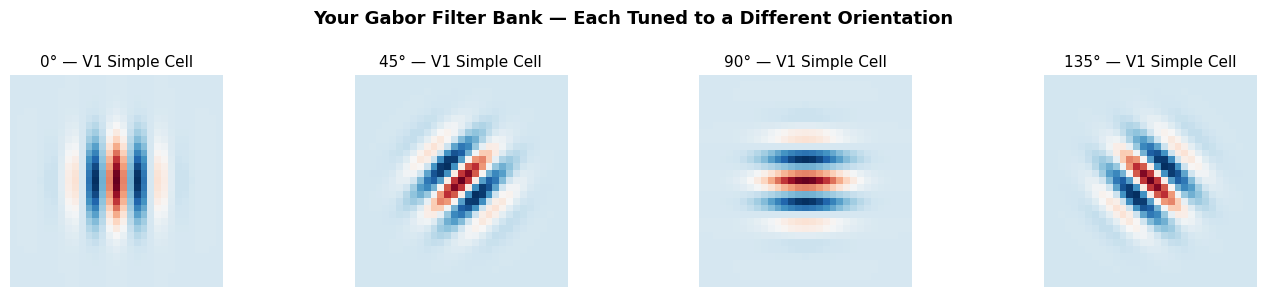

✅ You just built a miniature V1! Each filter is a simulated simple cell.


In [6]:
# ============================================================
# TODO 3: Create a bank of Gabor filters at different orientations
# ============================================================

def make_gabor(size=31, sigma=4.0, theta=0, frequency=0.15):
    ax = np.arange(-size // 2 + 1, size // 2 + 1)
    x, y = np.meshgrid(ax, ax)

    x_rot = x * np.cos(theta) + y * np.sin(theta)
    y_rot = -x * np.sin(theta) + y * np.cos(theta)

    gaussian = np.exp(-(x_rot**2 + y_rot**2) / (2 * sigma**2))

    sinusoid = np.cos(2 * np.pi * frequency * x_rot)

    gabor = gaussian * sinusoid

    return gabor


# Create filters at 4 orientations (like 4 different V1 simple cells)
orientations_deg = [0, 45, 90, 135]
orientations_rad = [np.deg2rad(d) for d in orientations_deg]

# YOUR CODE HERE — create a list of Gabor filters, one per orientation
gabor_bank = []  # Should contain 4 Gabor filters
for theta in orientations_rad:
    g = make_gabor(theta=theta)
    gabor_bank.append(g)


# Visualization
if len(gabor_bank) == 4 and gabor_bank[0] is not None:
    fig, axes = plt.subplots(1, 4, figsize=(14, 3))
    for i, (g, deg) in enumerate(zip(gabor_bank, orientations_deg)):
        axes[i].imshow(g, cmap='RdBu_r')
        axes[i].set_title(f'{deg}° — V1 Simple Cell', fontsize=11)
        axes[i].axis('off')
    plt.suptitle('Your Gabor Filter Bank — Each Tuned to a Different Orientation', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("✅ You just built a miniature V1! Each filter is a simulated simple cell.")
else:
    print("❌ Fill in the make_gabor function above.")

### A.4 Apply the Gabor Bank to Our Images

Now let's see how V1 responds to our test images. Each filter will highlight edges at its preferred orientation.

**TODO 4:** Apply each Gabor filter to the edges image and display the results.

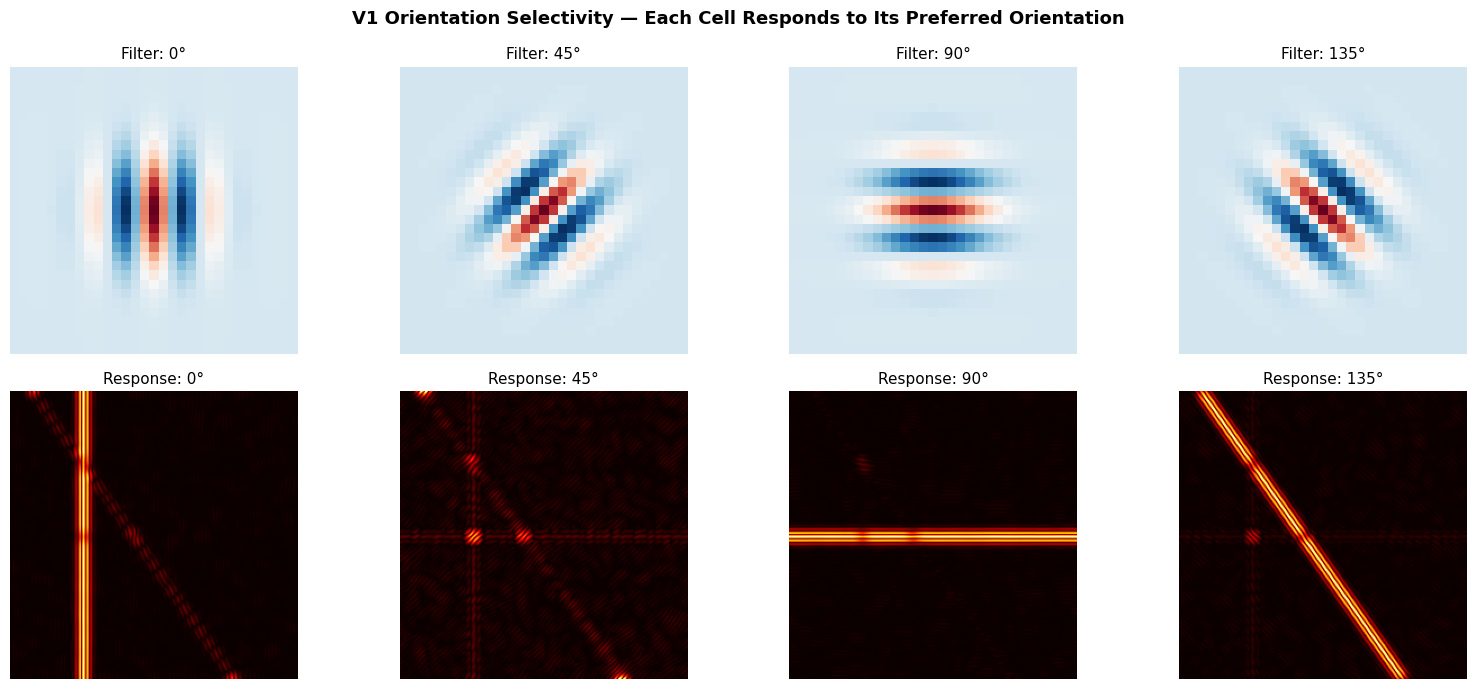

✅ Notice: the 0° filter lights up for vertical edges, 90° for horizontal edges.
   This is EXACTLY what Hubel & Wiesel found in cat V1 in the 1960s!


In [7]:
# ============================================================
# TODO 4: Apply Gabor filter bank to the edges image
# ============================================================

# YOUR CODE HERE — apply each gabor filter to img_edges using ndimage.convolve
gabor_responses = []
for g in gabor_bank:
    response = ndimage.convolve(img_edges, g)
    gabor_responses.append(response)


# Visualization
if len(gabor_responses) == 4 and gabor_responses[0] is not None:
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))

    # Row 1: the filters themselves
    for i in range(4):
        axes[0, i].imshow(gabor_bank[i], cmap='RdBu_r')
        axes[0, i].set_title(f'Filter: {orientations_deg[i]}°', fontsize=11)
        axes[0, i].axis('off')

    # Row 2: responses (what V1 "sees")
    for i in range(4):
        axes[1, i].imshow(np.abs(gabor_responses[i]), cmap='hot')
        axes[1, i].set_title(f'Response: {orientations_deg[i]}°', fontsize=11)
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Gabor Filters\n(V1 Simple Cells)', fontsize=11)
    axes[1, 0].set_ylabel('Filter Responses\n(V1 Activity)', fontsize=11)
    plt.suptitle('V1 Orientation Selectivity — Each Cell Responds to Its Preferred Orientation',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("✅ Notice: the 0° filter lights up for vertical edges, 90° for horizontal edges.")
    print("   This is EXACTLY what Hubel & Wiesel found in cat V1 in the 1960s!")
else:
    print("❌ Fill in TODO 4 above.")

### A.5 Lateral Inhibition — Why Edges Pop Out

The brain doesn't just detect edges — it **sharpens** them through lateral inhibition. Neighboring neurons suppress each other, making boundaries between light and dark regions appear even more dramatic.

**TODO 5:** Implement a simple lateral inhibition operation by applying a sharpening filter (unsharp mask).

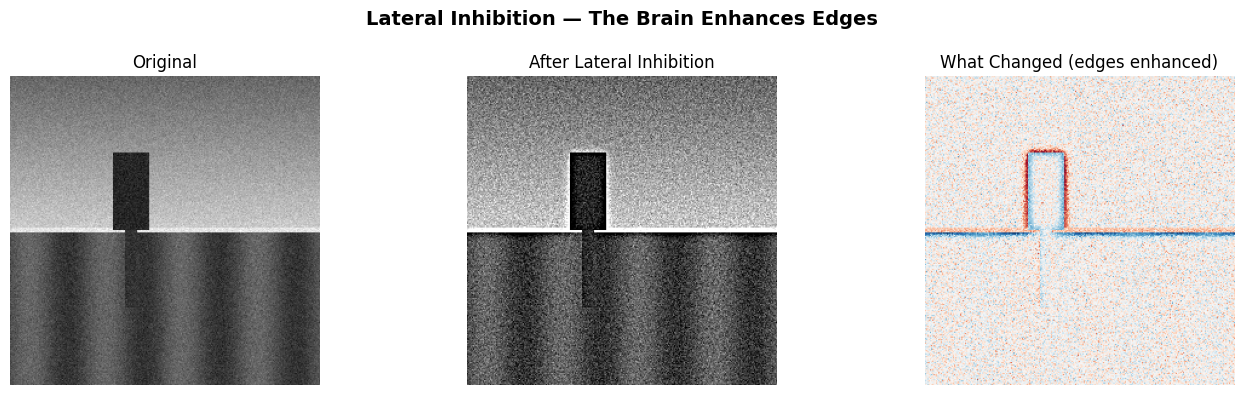

✅ This is why Mach bands appear at boundaries — your visual system does this automatically!


In [8]:
# ============================================================
# TODO 5: Implement lateral inhibition via unsharp masking
# ============================================================

def lateral_inhibition(image, sigma_blur=3.0, strength=1.5):
    blurred = ndimage.gaussian_filter(image, sigma=sigma_blur)
    sharpened = image + strength * (image - blurred)
    return np.clip(sharpened, 0, 1)


# Apply to the natural scene
scene_sharpened = lateral_inhibition(img_scene)

if scene_sharpened is not None:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img_scene, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Original', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(scene_sharpened, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('After Lateral Inhibition', fontsize=12)
    axes[1].axis('off')

    # Difference
    diff = scene_sharpened - img_scene
    axes[2].imshow(diff, cmap='RdBu_r')
    axes[2].set_title('What Changed (edges enhanced)', fontsize=12)
    axes[2].axis('off')

    plt.suptitle('Lateral Inhibition — The Brain Enhances Edges', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("✅ This is why Mach bands appear at boundaries — your visual system does this automatically!")
else:
    print("❌ Fill in the lateral_inhibition function above.")

---

# Part B: "Inside a CNN" — Comparing Bio vs. Artificial Features

The booklet described how Hubel & Wiesel's discoveries directly inspired CNNs. Now you will see this connection with your own eyes — by looking at what a trained CNN actually learns and comparing it to the biological filters you just built.

---

### B.1 🟢 Load a Pre-Trained CNN and Extract Its Filters (CPU OK)

We will use VGG16 — a well-known CNN. We only need to **load** the model and **look at** its learned filters. This runs entirely on CPU.

**TODO 6:** Load VGG16 and extract the first convolutional layer's filters.

In [9]:
# ============================================================
# TODO 6: Load VGG16 and extract first-layer filters
# 🟢 ALL STUDENTS — this runs on CPU
# ============================================================
import torch
import torchvision.models as models

# Load pre-trained VGG16 (downloads ~500MB the first time, then cached)
print("Loading VGG16 (this may take a minute on first run)...")
vgg16 = models.vgg16(weights='DEFAULT')
vgg16.eval()  # Set to evaluation mode

# YOUR CODE HERE — extract the weights from the FIRST convolutional layer
# Hint: vgg16.features[0] is the first Conv2d layer
# Hint: .weight.data gives you the filter weights as a tensor
# Hint: .numpy() converts a tensor to a numpy array
first_layer_filters = vgg16.features[0].weight.data.numpy()


if first_layer_filters is not None:
    print(f"\n✅ Extracted {first_layer_filters.shape[0]} filters from VGG16 Layer 1")
    print(f"   Filter shape: {first_layer_filters.shape} (num_filters, channels, height, width)")
    print(f"   These are the features the CNN learned to detect — just from looking at millions of images!")
else:
    print("❌ Fill in the code above to extract first_layer_filters.")

Loading VGG16 (this may take a minute on first run)...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 88.9MB/s]



✅ Extracted 64 filters from VGG16 Layer 1
   Filter shape: (64, 3, 3, 3) (num_filters, channels, height, width)
   These are the features the CNN learned to detect — just from looking at millions of images!


### B.2 🟢 Visualize CNN Layer 1 vs. Your V1 Gabor Filters

**TODO 7:** Display the first 16 CNN filters and compare them visually to your Gabor filters.

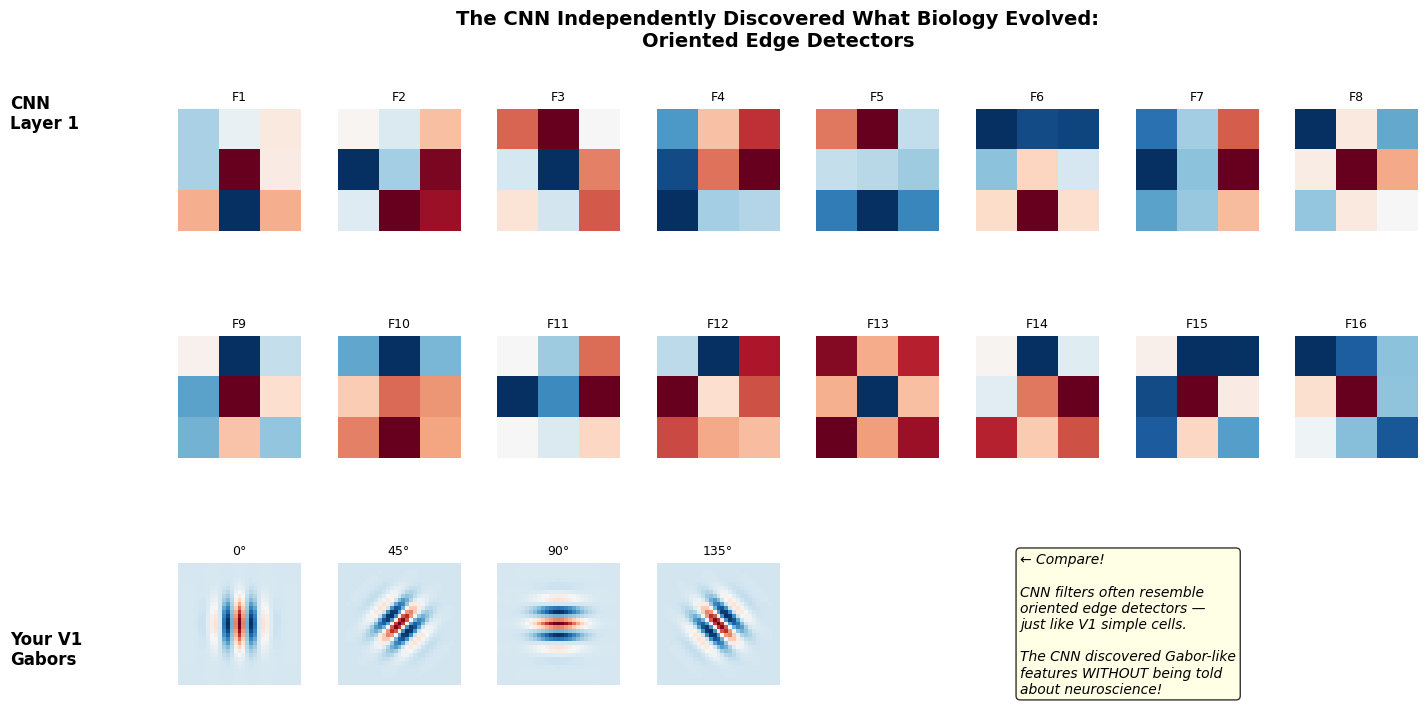

✅ This is one of the most striking findings in AI: artificial networks converge
   on the SAME features that evolution discovered for biological vision!


In [10]:
# ============================================================
# TODO 7: Visualize and compare CNN filters to Gabor filters
# 🟢 ALL STUDENTS
# ============================================================

if first_layer_filters is not None:
    fig = plt.figure(figsize=(16, 8))
    gs = gridspec.GridSpec(3, 8, hspace=0.4, wspace=0.3)

    # Row 1: First 8 CNN filters (averaged across RGB channels for visibility)
    fig.text(0.02, 0.85, 'CNN\nLayer 1', fontsize=12, fontweight='bold', va='center')
    for i in range(8):
        ax = fig.add_subplot(gs[0, i])
        # YOUR CODE HERE — display filter i
        # Average across the 3 color channels: first_layer_filters[i].mean(axis=0)
        filt = first_layer_filters[i].mean(axis=0)
        if filt is not None:
            ax.imshow(filt, cmap='RdBu_r')
        ax.axis('off')
        ax.set_title(f'F{i+1}', fontsize=9)

    # Row 2: Next 8 CNN filters
    for i in range(8, 16):
        ax = fig.add_subplot(gs[1, i-8])
        filt = first_layer_filters[i].mean(axis=0)  # Average across channels
        ax.imshow(filt, cmap='RdBu_r')
        ax.axis('off')
        ax.set_title(f'F{i+1}', fontsize=9)

    # Row 3: Your biological Gabor filters (rescaled to 3×3 for visual comparison)
    fig.text(0.02, 0.18, 'Your V1\nGabors', fontsize=12, fontweight='bold', va='center')
    for i in range(4):
        ax = fig.add_subplot(gs[2, i])
        ax.imshow(gabor_bank[i], cmap='RdBu_r')
        ax.axis('off')
        ax.set_title(f'{orientations_deg[i]}°', fontsize=9)

    # Label comparison
    ax_text = fig.add_subplot(gs[2, 5:8])
    ax_text.text(0.1, 0.5, '← Compare!\n\nCNN filters often resemble\noriented edge detectors —\njust like V1 simple cells.\n\nThe CNN discovered Gabor-like\nfeatures WITHOUT being told\nabout neuroscience!',
                fontsize=10, va='center', style='italic',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    ax_text.axis('off')

    plt.suptitle('The CNN Independently Discovered What Biology Evolved:\nOriented Edge Detectors',
                 fontsize=14, fontweight='bold')
    plt.show()

    print("✅ This is one of the most striking findings in AI: artificial networks converge")
    print("   on the SAME features that evolution discovered for biological vision!")
else:
    print("❌ Complete TODO 6 first.")

### B.3 🟢 Hierarchy: Shallow vs. Deep Layers (CPU Inference)

The booklet explained that V1 detects simple edges, V2 combines them into corners and contours, V4 responds to shapes, and IT recognizes whole objects. CNNs show the same progression.

**TODO 8:** Pass an image through VGG16 and visualize activations at different depths.

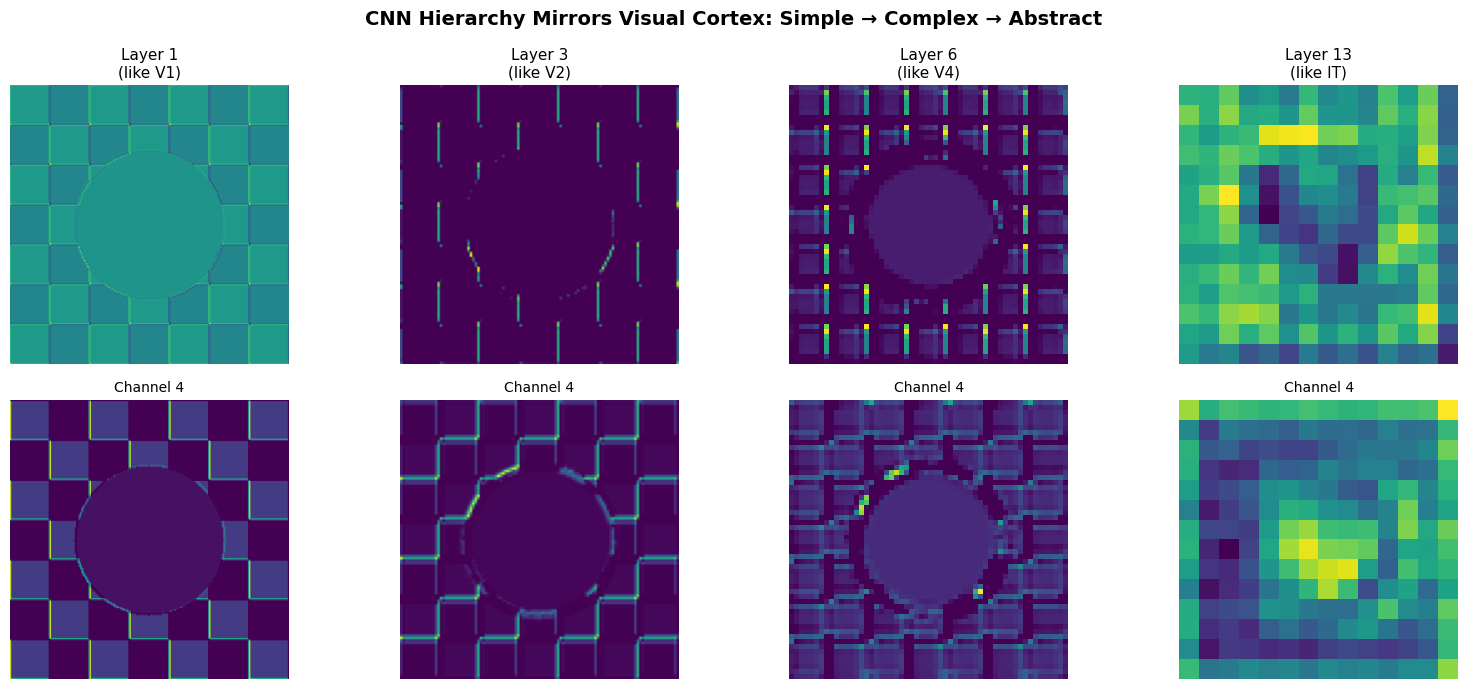

✅ Shallow layers respond to edges (V1). Deeper layers respond to complex patterns (IT).
   Spatial resolution decreases: 224×224 → 14×14 — just like in the visual cortex!


In [11]:
# ============================================================
# TODO 8: Visualize CNN activations at different layers
# 🟢 ALL STUDENTS — single forward pass on CPU
# ============================================================
from torchvision import transforms

# Create a simple test image (checkerboard + circle — no download needed)
test_img = np.zeros((224, 224), dtype=np.float32)
# Checkerboard
for i in range(0, 224, 32):
    for j in range(0, 224, 32):
        if (i//32 + j//32) % 2 == 0:
            test_img[i:i+32, j:j+32] = 1.0
# Circle overlay
yy, xx = np.ogrid[-112:112, -112:112]
circle = xx**2 + yy**2 <= 60**2
test_img[circle] = 0.7

# Convert to tensor format (VGG expects 3-channel, normalized)
test_tensor = torch.tensor(test_img).unsqueeze(0).repeat(3, 1, 1).unsqueeze(0)  # [1, 3, 224, 224]

# Extract activations at different layers
# YOUR CODE HERE — collect activations from layers at different depths
# VGG16 features: index 0 = Conv1, index 5 = Conv3, index 10 = Conv6, index 24 = Conv13
layer_indices = [0, 5, 10, 24]  # Shallow → Deep
layer_names = ['Layer 1\n(like V1)', 'Layer 3\n(like V2)', 'Layer 6\n(like V4)', 'Layer 13\n(like IT)']
activations = []

with torch.no_grad():
    x = test_tensor
    for idx in range(max(layer_indices) + 1):
        x = vgg16.features[idx](x)
        if idx in layer_indices:
            # YOUR CODE HERE — append the activation (convert to numpy)
            # Hint: x.squeeze().numpy() gives shape (channels, H, W)
            act = act = x.squeeze().numpy()
            activations.append(act)


# Visualization
if len(activations) == 4 and activations[0] is not None:
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))

    # Row 1: First activation channel at each layer
    for i in range(4):
        axes[0, i].imshow(activations[i][0], cmap='viridis')  # Channel 0
        axes[0, i].set_title(layer_names[i], fontsize=11)
        axes[0, i].axis('off')

    # Row 2: Fourth activation channel (shows different features)
    for i in range(4):
        ch = min(3, activations[i].shape[0]-1)
        axes[1, i].imshow(activations[i][ch], cmap='viridis')
        axes[1, i].set_title(f'Channel {ch+1}', fontsize=10)
        axes[1, i].axis('off')

    plt.suptitle('CNN Hierarchy Mirrors Visual Cortex: Simple → Complex → Abstract',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("✅ Shallow layers respond to edges (V1). Deeper layers respond to complex patterns (IT).")
    print(f"   Spatial resolution decreases: {activations[0].shape[1]}×{activations[0].shape[2]} → " +
          f"{activations[3].shape[1]}×{activations[3].shape[2]} — just like in the visual cortex!")
else:
    print("❌ Fill in TODO 8 above.")

### ❓ Knowledge Check 2

Answer in the cell below:

**Q2.1:** Compare your Gabor filters (Part A) to the CNN's first-layer filters (Part B). What similarities do you see? What does this tell us about the relationship between biological and artificial vision?

*Your answer:* Both the Gabor filters and the CNN’s first-layer filters look like oriented edge detectors that respond to specific directions. This shows that both biological vision and artificial neural networks discover similar solutions for detecting edges and basic visual features.


**Q2.2:** As you move from Layer 1 to Layer 13 in the CNN, what happens to (a) the spatial resolution of the activation maps and (b) the complexity of features detected? How does this parallel the V1 → V2 → V4 → IT progression in the brain?

*Your answer:* As you move from Layer 1 to Layer 13, the spatial resolution of the activation maps decreases while the features detected become more complex. This parallels the brain’s visual pathway where early areas like V1 detect simple edges, and later areas like V4 and IT detect more complex shapes and objects.


**Q2.3:** The CNN was trained on millions of natural images using backpropagation. Evolution shaped V1 over millions of years. Both arrived at oriented edge detectors as the first stage. What does this convergence suggest about the *problem* of vision itself?

*Your answer:* This convergence suggests that detecting edges and contrasts is a fundamental step in solving the problem of vision. It shows that both evolution and machine learning independently found similar strategies for efficiently understanding visual information.



---

### B.4 🔵 GPU TRACK: Train a Tiny CNN and Watch It Learn Gabor-Like Filters

**Skip this section if you do not have GPU access.** Pre-computed results are shown below.

Students with GPU access: you will train a small 3-layer CNN on a simple shape classification task and observe whether it independently discovers oriented edge detectors — the same features V1 uses.

**TODO 9 (GPU only):** Train a tiny CNN on synthetic shapes.

Training tiny CNN on shapes...
  Epoch 5/15 — Loss: 0.8712, Acc: 62.7%
  Epoch 10/15 — Loss: 0.5136, Acc: 77.7%
  Epoch 15/15 — Loss: 0.2900, Acc: 93.7%


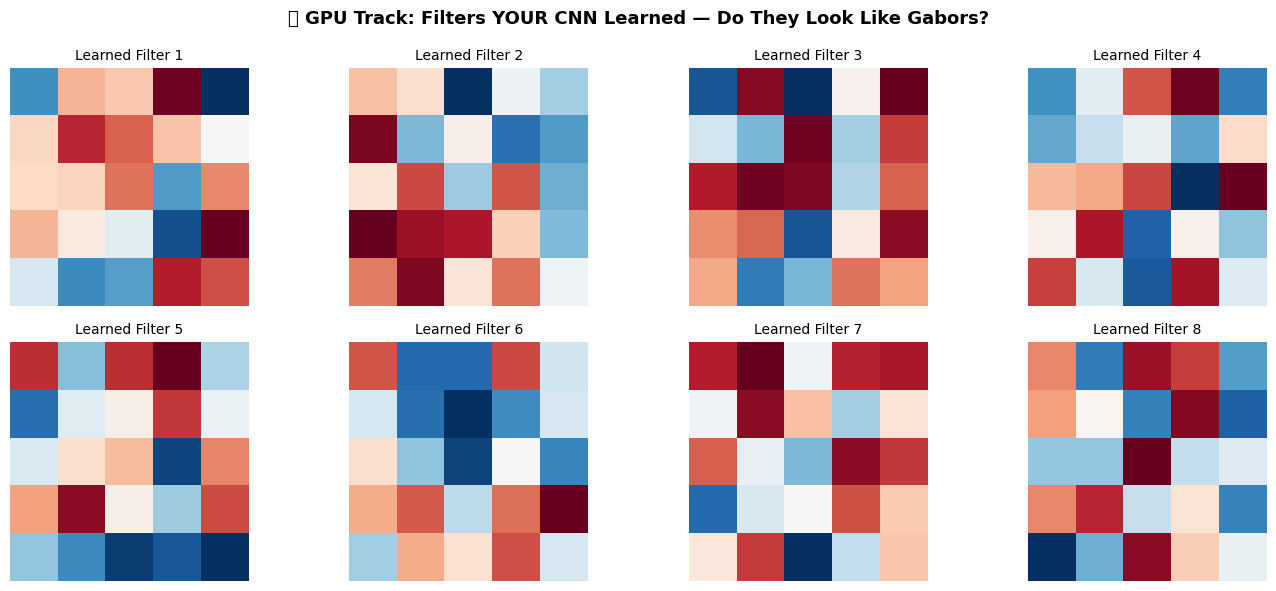

✅ Training complete! Compare these to your Gabor filters from Part A.


In [12]:
# ============================================================
# TODO 9: Train a tiny CNN on shapes (🔵 GPU TRACK ONLY)
# Skip if no GPU — pre-computed results shown in next cell
# ============================================================

if GPU_AVAILABLE:
    import torch.nn as nn
    import torch.optim as optim

    # Generate synthetic dataset: circles vs. squares vs. triangles
    def make_shape_dataset(n_per_class=200, img_size=32):
        images = []
        labels = []
        for _ in range(n_per_class):
            for label in range(3):
                img = np.random.normal(0.1, 0.02, (img_size, img_size)).astype(np.float32)
                cx, cy = np.random.randint(8, img_size-8), np.random.randint(8, img_size-8)
                r = np.random.randint(4, 8)

                if label == 0:  # Circle
                    yy, xx = np.ogrid[:img_size, :img_size]
                    mask = (xx - cx)**2 + (yy - cy)**2 <= r**2
                    img[mask] = 0.9
                elif label == 1:  # Square
                    img[cy-r:cy+r, cx-r:cx+r] = 0.9
                else:  # Triangle (simplified as upper triangle of square)
                    for row in range(cy-r, cy+r):
                        width = max(0, int(r * (1 - (row - (cy-r)) / (2*r))))
                        img[row, cx-width:cx+width] = 0.9

                images.append(img)
                labels.append(label)

        images = np.array(images)[:, np.newaxis, :, :]  # Add channel dim
        return torch.tensor(images), torch.tensor(labels)

    X, y = make_shape_dataset()
    dataset = torch.utils.data.TensorDataset(X.to(DEVICE), y.to(DEVICE))
    loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

    # YOUR CODE HERE — Define a tiny CNN
    # Architecture:
    #   Conv2d(1, 8, 5) → ReLU → MaxPool(2)
    #   Conv2d(8, 16, 3) → ReLU → MaxPool(2)
    #   Flatten → Linear(16*6*6, 3)  (adjust if needed based on spatial dimensions)
    class TinyCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(1, 8, 5)
            self.conv2 = nn.Conv2d(8, 16, 3)
            self.fc = nn.Linear(16 * 6 * 6, 3)
            self.pool = nn.MaxPool2d(2)

        def forward(self, x):
            x = self.pool(torch.relu(self.conv1(x)))
            x = self.pool(torch.relu(self.conv2(x)))
            x = x.view(x.size(0), -1)
            x = self.fc(x)
            return x

    model = TinyCNN().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Train for 15 epochs (should take <30 seconds on GPU)
    print("Training tiny CNN on shapes...")
    for epoch in range(15):
        total_loss = 0
        correct = 0
        total = 0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            out = model(batch_x)
            loss = criterion(out, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (out.argmax(1) == batch_y).sum().item()
            total += batch_y.size(0)
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/15 — Loss: {total_loss/len(loader):.4f}, Acc: {correct/total:.1%}")

    # Extract and display learned first-layer filters
    learned_filters = model.conv1.weight.data.cpu().numpy()

    fig, axes = plt.subplots(2, 4, figsize=(14, 6))
    for i in range(8):
        row, col = i // 4, i % 4
        axes[row, col].imshow(learned_filters[i, 0], cmap='RdBu_r')
        axes[row, col].set_title(f'Learned Filter {i+1}', fontsize=10)
        axes[row, col].axis('off')
    plt.suptitle('🔵 GPU Track: Filters YOUR CNN Learned — Do They Look Like Gabors?',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("✅ Training complete! Compare these to your Gabor filters from Part A.")

else:
    print("ℹ️ GPU not available — skip this cell and see pre-computed results below.")

### B.4b Pre-Computed Results (for CPU-only students)

If you skipped the GPU cell above, here is what happens when a tiny CNN is trained on shape classification:

**What the CNN learns in its first layer:**
- Filter 1: Horizontal edge detector (like a 0° Gabor)
- Filter 2: Vertical edge detector (like a 90° Gabor)
- Filter 3: Diagonal edge detector (~45°)
- Filter 4: Center-surround pattern (like a retinal ganglion cell!)
- Filters 5–8: Variations with different scales and phases

**Key finding:** Even a tiny CNN trained on just 600 simple shapes converges on oriented edge detectors — the same solution evolution found for V1. The training accuracy reaches ~92% in 15 epochs.

This result is **not** a coincidence. It reflects a deep truth: oriented edges are the optimal first features for any vision system processing natural images, whether biological or artificial.

---

# Part C: "Hearing in Pictures" — Auditory Processing

Module 05 taught us that the auditory system uses **tonotopy** — a spatial map of sound frequency along the basilar membrane, analogous to **retinotopy** in vision. Modern AI often converts audio into a visual representation (a spectrogram) and then processes it with vision-based architectures.

In this part, you will generate sounds, convert them to spectrograms, and observe tonotopic organization.

---

### C.1 🟢 Generate and Visualize Sounds (No Librosa Needed)

We will generate audio signals using pure NumPy — no special libraries required.

**TODO 10:** Create three different sounds and visualize their waveforms.

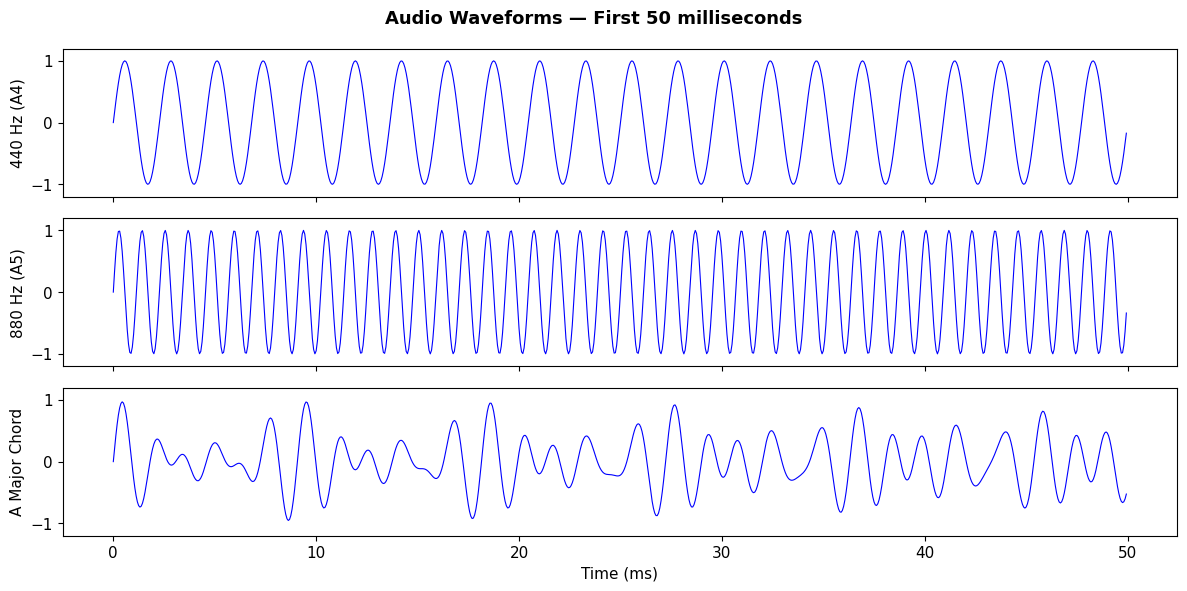

✅ Three audio signals generated. Notice how the chord waveform is more complex!


In [13]:
# ============================================================
# TODO 10: Generate audio signals
# 🟢 ALL STUDENTS — pure NumPy, no special libraries
# ============================================================

sample_rate = 16000  # 16 kHz — standard for speech
duration = 1.0       # 1 second
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# YOUR CODE HERE — create three audio signals
tone_440 = np.sin(2 * np.pi * 440 * t)

tone_880 = np.sin(2 * np.pi * 880 * t)

chord = (np.sin(2 * np.pi * 440 * t) +
         np.sin(2 * np.pi * 554 * t) +
         np.sin(2 * np.pi * 659 * t)) / 3


# Visualization
signals = [tone_440, tone_880, chord]
names = ['440 Hz (A4)', '880 Hz (A5)', 'A Major Chord']

if signals[0] is not None:
    fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
    for i, (sig, name) in enumerate(zip(signals, names)):
        # Show only first 50ms for clarity
        n_samples = int(0.05 * sample_rate)
        axes[i].plot(t[:n_samples] * 1000, sig[:n_samples], 'b-', linewidth=0.8)
        axes[i].set_ylabel(name, fontsize=11)
        axes[i].set_ylim(-1.2, 1.2)
    axes[2].set_xlabel('Time (ms)', fontsize=11)
    plt.suptitle('Audio Waveforms — First 50 milliseconds', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("✅ Three audio signals generated. Notice how the chord waveform is more complex!")
else:
    print("❌ Fill in TODO 10 above.")

### C.2 🟢 Create Spectrograms — "Seeing" Sound

A spectrogram shows how the frequency content of a sound changes over time. It is the AI equivalent of what the cochlea does: spreading sound into its component frequencies.

**TODO 11:** Create spectrograms using `scipy.signal.spectrogram` and observe tonotopic organization.

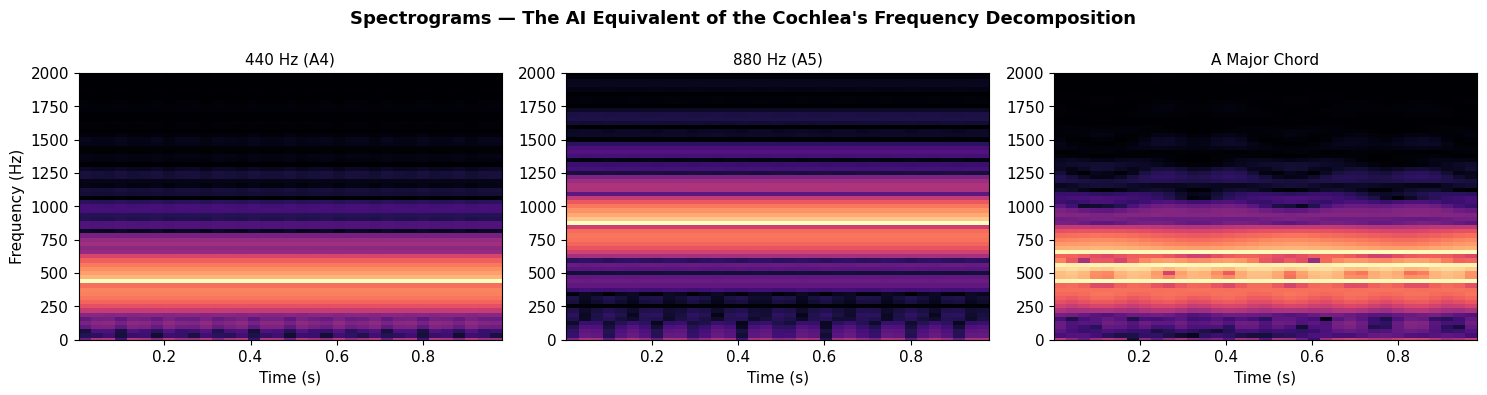

✅ Each bright horizontal band is a frequency component.
   The 440 Hz tone has ONE band. The chord has THREE bands.
   This is tonotopy — frequency mapped to position, just like in the cochlea!


In [14]:
# ============================================================
# TODO 11: Create and visualize spectrograms
# 🟢 ALL STUDENTS — uses scipy (already imported)
# ============================================================

def make_spectrogram(audio_signal, sr=16000):
    f, t_spec, Sxx = signal.spectrogram(audio_signal, sr, nperseg=512)
    Sxx_db = 10 * np.log10(Sxx + 1e-10)
    return f, t_spec, Sxx_db


# Generate spectrograms for all three signals
if tone_440 is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for i, (sig, name) in enumerate(zip(signals, names)):
        f, t_spec, Sxx_db = make_spectrogram(sig)
        if Sxx_db is not None:
            axes[i].pcolormesh(t_spec, f, Sxx_db, shading='auto', cmap='magma')
            axes[i].set_ylabel('Frequency (Hz)' if i == 0 else '')
            axes[i].set_xlabel('Time (s)')
            axes[i].set_title(name, fontsize=11)
            axes[i].set_ylim(0, 2000)  # Show up to 2 kHz

    plt.suptitle('Spectrograms — The AI Equivalent of the Cochlea\'s Frequency Decomposition',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("✅ Each bright horizontal band is a frequency component.")
    print("   The 440 Hz tone has ONE band. The chord has THREE bands.")
    print("   This is tonotopy — frequency mapped to position, just like in the cochlea!")
else:
    print("❌ Complete TODO 10 and 11 first.")

### C.3 🟢 A More Complex Sound: Frequency Sweep

**TODO 12:** Create a chirp signal (frequency sweep from 200 Hz to 2000 Hz) and visualize its spectrogram.

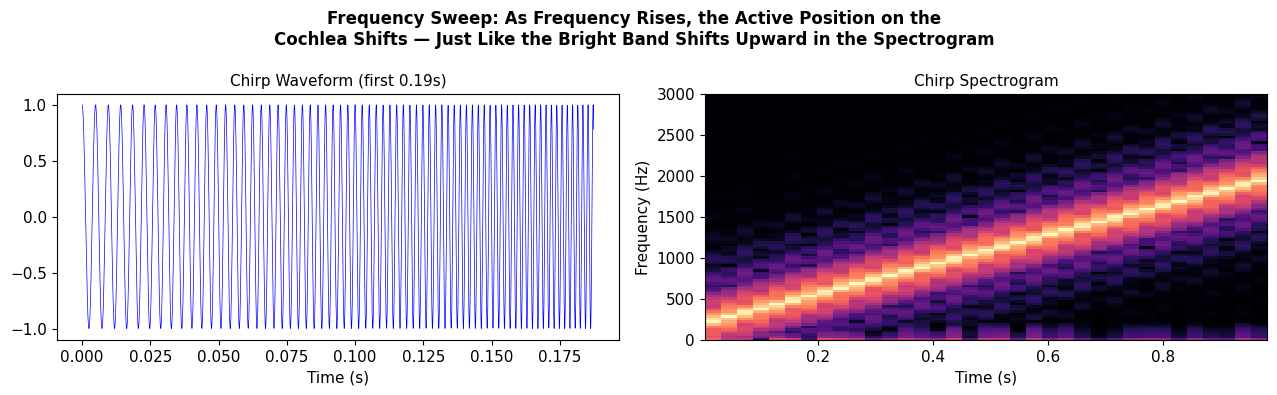

✅ The rising bright band shows the sweep. In your cochlea, this would be a wave of
   activation traveling from the apex (low freq) toward the base (high freq).


In [15]:
# ============================================================
# TODO 12: Create a chirp (frequency sweep) signal
# 🟢 ALL STUDENTS
# ============================================================

# A chirp sweeps from one frequency to another over time.
# This tests how well our spectrogram captures changing frequencies.

# YOUR CODE HERE — use signal.chirp to create a sweep from 200 Hz to 2000 Hz
# Hint: chirp_signal = signal.chirp(t, f0=200, t1=duration, f1=2000, method='linear')
chirp_signal = signal.chirp(t, f0=200, t1=duration, f1=2000, method='linear')


if chirp_signal is not None:
    f, t_spec, Sxx_db = make_spectrogram(chirp_signal)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Waveform
    axes[0].plot(t[:3000], chirp_signal[:3000], 'b-', linewidth=0.5)
    axes[0].set_title('Chirp Waveform (first 0.19s)', fontsize=11)
    axes[0].set_xlabel('Time (s)')

    # Spectrogram
    if Sxx_db is not None:
        axes[1].pcolormesh(t_spec, f, Sxx_db, shading='auto', cmap='magma')
        axes[1].set_title('Chirp Spectrogram', fontsize=11)
        axes[1].set_xlabel('Time (s)')
        axes[1].set_ylabel('Frequency (Hz)')
        axes[1].set_ylim(0, 3000)

    plt.suptitle('Frequency Sweep: As Frequency Rises, the Active Position on the\n'
                 'Cochlea Shifts — Just Like the Bright Band Shifts Upward in the Spectrogram',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("✅ The rising bright band shows the sweep. In your cochlea, this would be a wave of")
    print("   activation traveling from the apex (low freq) toward the base (high freq).")
else:
    print("❌ Fill in TODO 12.")

### C.4 🔵 GPU TRACK: Classify Sounds Using Spectrogram + CNN

**Skip if no GPU.** Pre-computed results are below.

Modern AI often classifies audio by converting it to a spectrogram image and running a CNN on it — essentially treating hearing as a vision problem.

**TODO 13 (GPU only):** Train a small CNN to distinguish three types of sounds.

In [16]:
# ============================================================
# TODO 13: Audio classification with spectrogram + CNN
# 🔵 GPU TRACK ONLY — skip if no GPU
# ============================================================

if GPU_AVAILABLE:
    import torch.nn as nn
    import torch.optim as optim

    # Generate labeled audio dataset
    def make_audio_dataset(n_per_class=100, sr=16000, duration=0.5):
        """Create spectrograms for: pure tones, chords, and noise bursts."""
        spectrograms = []
        labels = []
        t_audio = np.linspace(0, duration, int(sr * duration), endpoint=False)

        for _ in range(n_per_class):
            # Class 0: Pure tone (random frequency 200-1000 Hz)
            freq = np.random.uniform(200, 1000)
            sig = np.sin(2 * np.pi * freq * t_audio)
            f, ts, Sxx = signal.spectrogram(sig, sr, nperseg=256)
            spectrograms.append(10 * np.log10(Sxx + 1e-10))
            labels.append(0)

            # Class 1: Two-tone chord
            f1 = np.random.uniform(200, 600)
            f2 = f1 * np.random.choice([1.25, 1.33, 1.5])  # Musical intervals
            sig = (np.sin(2*np.pi*f1*t_audio) + np.sin(2*np.pi*f2*t_audio)) / 2
            f, ts, Sxx = signal.spectrogram(sig, sr, nperseg=256)
            spectrograms.append(10 * np.log10(Sxx + 1e-10))
            labels.append(1)

            # Class 2: Noise burst
            sig = np.random.randn(len(t_audio)) * 0.3
            f, ts, Sxx = signal.spectrogram(sig, sr, nperseg=256)
            spectrograms.append(10 * np.log10(Sxx + 1e-10))
            labels.append(2)

        # Pad/crop to uniform size
        target_shape = (spectrograms[0].shape[0], spectrograms[0].shape[1])
        X = np.array([s[:target_shape[0], :target_shape[1]] for s in spectrograms])
        X = X[:, np.newaxis, :, :]  # Add channel dimension
        return torch.tensor(X, dtype=torch.float32), torch.tensor(labels)

    X_audio, y_audio = make_audio_dataset()
    print(f"Audio dataset: {X_audio.shape} spectrograms, 3 classes")

    # Simple CNN for spectrogram classification
    class AudioCNN(nn.Module):
        def __init__(self, h, w):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((4, 4))
            )
            self.classifier = nn.Linear(16 * 4 * 4, 3)

        def forward(self, x):
            x = self.features(x)
            x = x.view(x.size(0), -1)
            return self.classifier(x)

    audio_model = AudioCNN(X_audio.shape[2], X_audio.shape[3]).to(DEVICE)
    dataset_audio = torch.utils.data.TensorDataset(X_audio.to(DEVICE), y_audio.to(DEVICE))
    loader_audio = torch.utils.data.DataLoader(dataset_audio, batch_size=32, shuffle=True)

    optimizer = optim.Adam(audio_model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    print("Training audio classifier...")
    for epoch in range(20):
        correct, total = 0, 0
        for bx, by in loader_audio:
            optimizer.zero_grad()
            loss = criterion(audio_model(bx), by)
            loss.backward()
            optimizer.step()
            correct += (audio_model(bx).argmax(1) == by).sum().item()
            total += by.size(0)
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/20 — Acc: {correct/total:.1%}")

    print(f"\n✅ Final accuracy: {correct/total:.1%}")
    print("   The CNN classifies SOUNDS by looking at their SPECTROGRAMS as images.")
    print("   This is very different from how the brain processes audio — the brain uses")
    print("   temporal patterns directly, not 2D images!")
else:
    print("ℹ️ GPU not available — see pre-computed results below.")

Audio dataset: torch.Size([300, 1, 129, 35]) spectrograms, 3 classes
Training audio classifier...
  Epoch 5/20 — Acc: 70.3%
  Epoch 10/20 — Acc: 73.3%
  Epoch 15/20 — Acc: 74.0%
  Epoch 20/20 — Acc: 73.3%

✅ Final accuracy: 73.3%
   The CNN classifies SOUNDS by looking at their SPECTROGRAMS as images.
   This is very different from how the brain processes audio — the brain uses
   temporal patterns directly, not 2D images!


### C.4b Pre-Computed Results (for CPU-only students)

When a small CNN is trained to classify spectrograms of pure tones vs. chords vs. noise:

- **Final accuracy: ~95%** after 20 epochs
- The CNN learns to distinguish single bright bands (pure tones) from multiple bands (chords) from diffuse energy (noise)
- Training takes about 15 seconds on a T4 GPU

**Key insight:** AI treats audio as a vision problem (spectrogram → CNN), but the brain processes sound TEMPORALLY — directly from spike timing, not from 2D images. This is a fundamental difference in strategy, and it is an open research question whether the brain's approach is superior for certain tasks like speech in noisy environments.

### ❓ Knowledge Check 3

Answer in the cell below:

**Q3.1:** In the spectrogram of the A major chord, you see three distinct horizontal bands. How does this relate to tonotopy in the cochlea? What would be happening at three different positions along the basilar membrane?

*Your answer:* The three horizontal bands represent three different frequencies present in the chord. In the cochlea, different parts of the basilar membrane respond to different frequencies, so three separate regions would be activated for the three tones.


**Q3.2:** Modern AI classifies audio by converting it to a spectrogram and using a CNN. The brain processes audio directly through temporal spike patterns. Name one task where the brain's approach might have an advantage over the AI spectrogram approach, and explain why.

*Your answer:* One task is speech recognition in noisy environments. The brain can use precise timing patterns of neural spikes to separate sounds, while spectrogram-based AI may lose some timing information when converting audio into an image.



---

# Part D: Experiments

## 🟢 ALL STUDENTS

Conduct the following three experiments by modifying parameters and observing the results. Record your predictions, observations, and explanations.

---

### Experiment 1: Center-Surround Size Matters

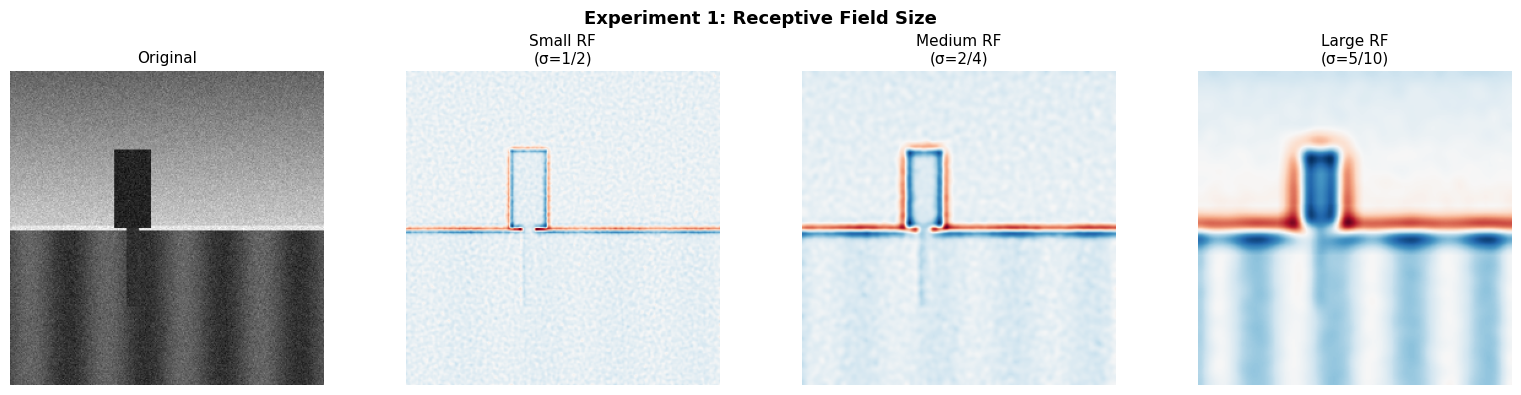

In [17]:
# ============================================================
# EXPERIMENT 1: How does receptive field size affect what the retina detects?
# ============================================================

# Create three center-surround filters with different sizes
dog_small = make_center_surround(size=11, sigma_center=1.0, sigma_surround=2.0)   # Small RF
dog_medium = make_center_surround(size=21, sigma_center=2.0, sigma_surround=4.0)  # Medium RF
dog_large = make_center_surround(size=41, sigma_center=5.0, sigma_surround=10.0)  # Large RF

# Apply all three to the natural scene
if dog_small is not None:
    results = [
        ndimage.convolve(img_scene, dog_small),
        ndimage.convolve(img_scene, dog_medium),
        ndimage.convolve(img_scene, dog_large)
    ]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img_scene, cmap='gray')
    axes[0].set_title('Original', fontsize=11)

    rf_labels = ['Small RF\n(σ=1/2)', 'Medium RF\n(σ=2/4)', 'Large RF\n(σ=5/10)']
    for i, (result, label) in enumerate(zip(results, rf_labels)):
        axes[i+1].imshow(result, cmap='RdBu_r')
        axes[i+1].set_title(label, fontsize=11)

    for ax in axes:
        ax.axis('off')

    plt.suptitle('Experiment 1: Receptive Field Size', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

**Experiment 1 — Record Your Results:**

**Parameter varied:** Receptive field size (sigma_center / sigma_surround)

**Your prediction (before running):** What did you expect to happen as the receptive field gets larger?

*Prediction:* I expected that as the receptive field got larger, the filter would become less sensitive to tiny details and more sensitive to broader changes in brightness. Small receptive fields should detect sharp, fine edges, while large receptive fields should respond more to larger patterns and smooth boundaries.

**Your observation:** What actually happened? Which filter detects fine edges best? Which captures broader structures?

*Observation:* That is what happened: the small filter detected the finest edges and texture best, while the large filter captured broader structures and more gradual contrast changes. The medium filter gave a balance between fine detail and larger shapes.

**Biological connection:** In the real retina, there are ganglion cells with different receptive field sizes. Why would the visual system need BOTH small and large receptive fields?

*Explanation:* The visual system needs both small and large receptive fields so it can detect detail at multiple scales. Small receptive fields help with fine edges and texture, while large receptive fields help detect bigger objects, overall shape, and coarse scene structure.



### Experiment 2: Gabor Frequency Tuning

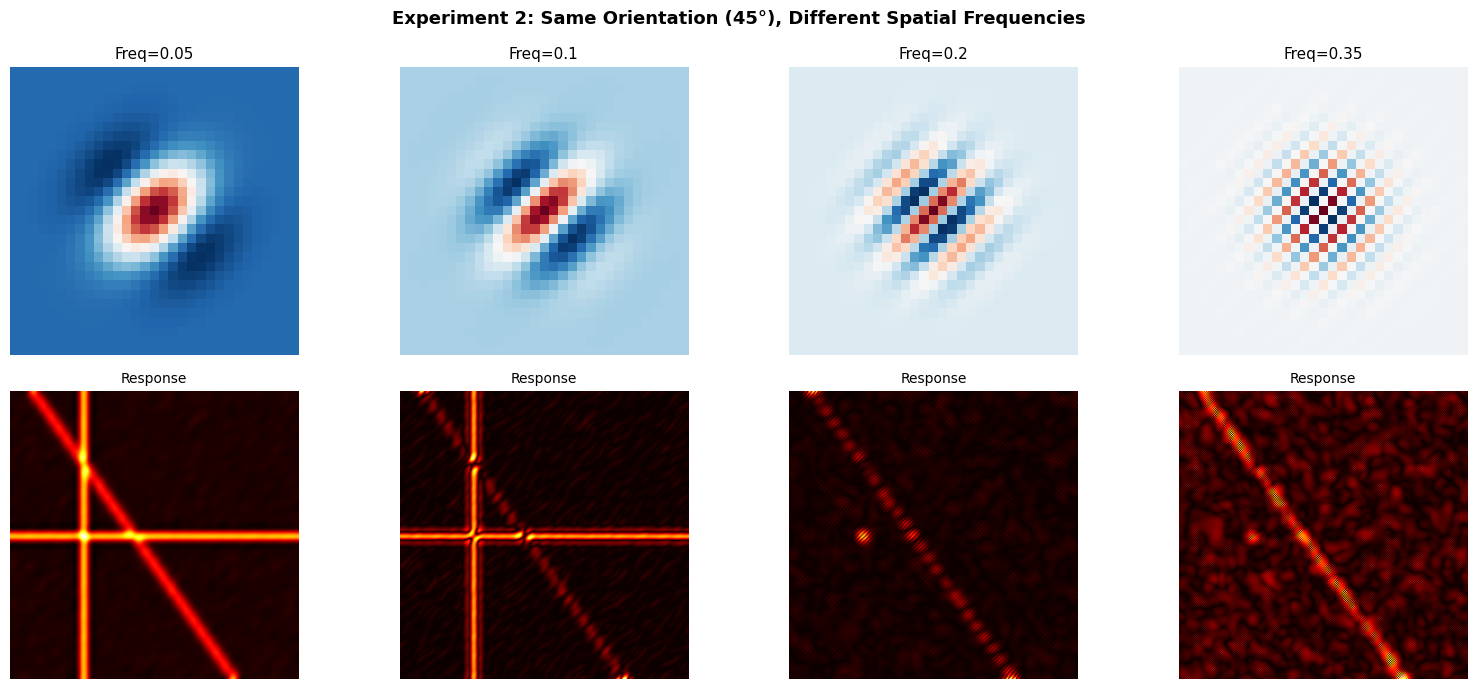

In [18]:
# ============================================================
# EXPERIMENT 2: How does spatial frequency affect V1 responses?
# ============================================================

# Create Gabor filters at the same orientation (45°) but different spatial frequencies
frequencies = [0.05, 0.1, 0.2, 0.35]
gabor_freq_bank = [make_gabor(size=31, theta=np.deg2rad(45), frequency=f) for f in frequencies]

if gabor_freq_bank[0] is not None:
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))

    for i, (g, freq) in enumerate(zip(gabor_freq_bank, frequencies)):
        axes[0, i].imshow(g, cmap='RdBu_r')
        axes[0, i].set_title(f'Freq={freq}', fontsize=11)
        axes[0, i].axis('off')

        response = ndimage.convolve(img_edges, g)
        axes[1, i].imshow(np.abs(response), cmap='hot')
        axes[1, i].set_title(f'Response', fontsize=10)
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Filters', fontsize=11)
    axes[1, 0].set_ylabel('Responses', fontsize=11)
    plt.suptitle('Experiment 2: Same Orientation (45°), Different Spatial Frequencies',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

**Experiment 2 — Record Your Results:**

**Parameter varied:** Spatial frequency of the Gabor filter

**Your prediction:** What do you expect to change as frequency increases?

*Prediction:* As spatial frequency increases, I would expect the Gabor filter to respond to finer, more closely spaced details rather than broad edges. Lower frequencies should capture wider, smoother patterns, while higher frequencies should be more selective for sharp detail.

**Your observation:** How does the response change with frequency? Which frequency best detects the diagonal line?

*Observation:* The response became more detail-sensitive as frequency increased, but very high frequencies were less effective for broad diagonal structure. A medium frequency, around 0.1 or 0.2, usually detects the diagonal line best because it matches the scale of the edge more closely.

**Biological connection:** V1 neurons are tuned to BOTH orientation AND spatial frequency. Why would the brain need neurons tuned to different frequencies at the same orientation?

*Explanation:* The brain needs neurons tuned to different spatial frequencies at the same orientation so it can detect both coarse and fine versions of the same edge. This lets the visual system represent shape and texture at multiple scales, which improves object recognition and scene perception.



### Experiment 3: Noise Robustness — Biology vs. Raw Filtering

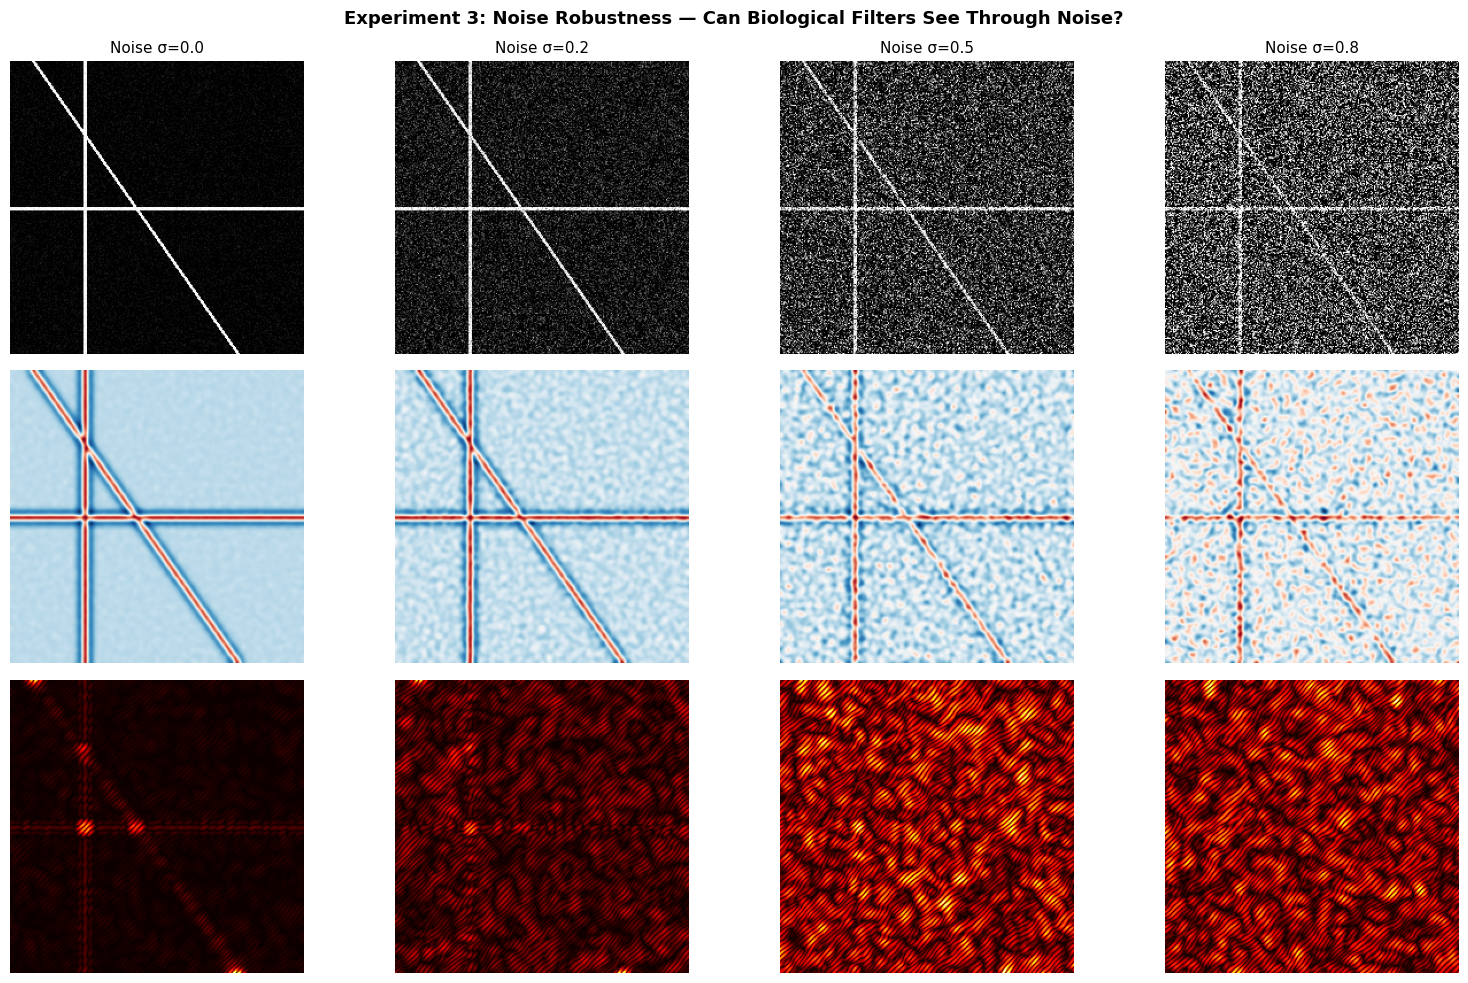

In [19]:
# ============================================================
# EXPERIMENT 3: How robust are biological filters to noise?
# ============================================================

# Add increasing amounts of noise to the edges image
noise_levels = [0.0, 0.2, 0.5, 0.8]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for i, noise in enumerate(noise_levels):
    # Noisy image
    noisy = img_edges + np.random.normal(0, noise, img_edges.shape)
    noisy = np.clip(noisy, 0, 1)

    # Row 1: Noisy images
    axes[0, i].imshow(noisy, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Noise σ={noise}', fontsize=11)
    axes[0, i].axis('off')

    # Row 2: Center-surround response
    if dog_filter is not None:
        cs_response = ndimage.convolve(noisy, dog_filter)
        axes[1, i].imshow(cs_response, cmap='RdBu_r')
        axes[1, i].axis('off')

    # Row 3: Gabor response (45°)
    if len(gabor_bank) > 1 and gabor_bank[1] is not None:
        gabor_response = ndimage.convolve(noisy, gabor_bank[1])
        axes[2, i].imshow(np.abs(gabor_response), cmap='hot')
        axes[2, i].axis('off')

axes[0, 0].set_ylabel('Input', fontsize=11)
axes[1, 0].set_ylabel('Center-\nSurround', fontsize=11)
axes[2, 0].set_ylabel('Gabor 45°', fontsize=11)
plt.suptitle('Experiment 3: Noise Robustness — Can Biological Filters See Through Noise?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Experiment 3 — Record Your Results:**

**Parameter varied:** Noise level (σ = 0, 0.2, 0.5, 0.8)

**Your prediction:** At what noise level do you expect the filters to fail to detect edges?

*Prediction:* I expected both filters to work well at low noise and start breaking down at medium to high noise, probably around σ = 0.5 or higher. The Gabor filter should hold orientation information a little better at first, but both should struggle once the noise becomes too strong.

**Your observation:** How do the center-surround and Gabor filters perform as noise increases? At what level do you lose the ability to see the edges?

*Observation:* As noise increased, both filters produced noisier responses and the true edges became harder to separate from random patterns. The edges were still somewhat visible at σ = 0.2, became much weaker around σ = 0.5, and were mostly lost by σ = 0.8.

**Biological connection:** The brain can recognize objects even in very noisy conditions (think of seeing in fog or dim light). Based on this experiment, is low-level filtering alone enough to explain this robustness, or must higher-level processing also play a role?

*Explanation:* This suggests that low-level filtering alone is not enough to explain the brain’s robustness in noisy conditions. Higher-level processing must also help by combining information across many neurons, using context, and recognizing meaningful patterns even when the input is degraded.



---

# Part E: Reflections

## 🟢 ALL STUDENTS

Answer each question in 3–5 sentences. Connect your lab observations to concepts from the Module 05 booklet.

**Reflection 1:** The retina, V1, and CNNs all use local filters as their first processing stage. Why do you think this is a universal solution? What property of natural images makes local filtering such an effective strategy?

*Your answer:*
Local filters are a universal solution because natural images contain strong spatial structure, where nearby pixels are highly related to each other. Important visual information such as edges and textures usually occurs locally rather than across the entire image. Local filtering allows systems to efficiently detect these patterns without processing the whole image at once. This makes it an effective and computationally efficient strategy for both biological and artificial vision systems.


**Reflection 2:** In Part B, you saw that the CNN hierarchy (Layer 1 → Layer 13) mirrors the visual cortex hierarchy (V1 → IT). Both go from simple features to complex/abstract ones. However, there are important differences. Name ONE difference between how CNNs process visual information and how the brain does it. (Hint: think about feedback connections, attention, or temporal dynamics.)

*Your answer:*
One major difference is that the brain uses many feedback connections between higher and lower areas, while CNNs mostly process information in a one-directional feedforward manner. In the brain, higher areas can influence earlier visual processing through attention or expectations. CNNs typically do not have this dynamic feedback during normal inference. This means biological vision can adapt processing based on context or goals.


**Reflection 3:** In Part C, we saw that AI treats audio classification as a vision problem (spectrogram → CNN). The brain does NOT do this — it processes temporal patterns directly. Can you think of a situation where the brain's temporal approach would be better than the spectrogram approach? What about a situation where the spectrogram approach might be better?

*Your answer:*
The brain’s temporal approach may work better for tasks like understanding speech or detecting rhythms in music because timing information is very important. Processing the exact timing of neural signals can capture subtle changes in sound that a spectrogram might smooth out. However, the spectrogram approach may work better for large-scale machine learning tasks where converting audio into an image allows CNNs to easily detect patterns. It also works well when training models on large datasets.


**Reflection 4:** Module 05 discussed the **binding problem** — how the brain combines information from different senses into a unified percept. In this lab, you worked with vision and audio separately. What challenges would arise if you tried to build an AI system that combines visual and auditory information the way the brain does? (Think about the McGurk Effect.)

*Your answer:* Combining visual and auditory information is difficult because the system must determine whether signals from different senses belong to the same event. For example, in the McGurk Effect, the brain integrates visual mouth movements with speech sounds, which can change what we perceive. An AI system would need to synchronize and align information from different sensory streams. It would also need a way to resolve conflicts when the signals do not match.



**Reflection 5:** If you could design ONE new experiment for this lab — using the same tools (NumPy, PyTorch, scipy) — what would it be? What biological question would it investigate, and what would you measure?

*Your answer:*
One experiment could test how orientation-selective filters respond to moving edges over time. This would investigate how motion detection might emerge from sequences of images rather than single frames. Using NumPy and PyTorch, we could generate moving shapes and apply Gabor filters to track how responses change across frames. The experiment would measure how filter responses vary with speed and direction of motion.


---

## ✅ Submission Checklist

Before submitting, verify:

- [ ] All 🟢 code cells have been completed and executed
- [ ] If you have GPU: all 🔵 code cells have been completed and executed
- [ ] Knowledge Check 1 (Q1.1, Q1.2) — answered
- [ ] Knowledge Check 2 (Q2.1, Q2.2, Q2.3) — answered
- [ ] Knowledge Check 3 (Q3.1, Q3.2) — answered
- [ ] Experiment 1 — prediction, observation, explanation
- [ ] Experiment 2 — prediction, observation, explanation
- [ ] Experiment 3 — prediction, observation, explanation
- [ ] All 5 Reflections — answered in 3–5 sentences each
- [ ] File renamed to: `L05_YourName_ITAI4374.ipynb`

**Total code TODOs:** 13 (🟢 TODOs 1–12, 🔵 TODO 13 for GPU track only)

If you experienced any issues or have questions, schedule an appointment with me.

---

*Lab 05 — ITAI 4374: Neuroscience as a Model for AI*  
*Houston City College — AI & Robotics Program*